# Garbage Classification on 6 classes
Carboard, glass, metal, paper, plastic, trash

# Dataset Description

Dataset source: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification

The Garbage Classification Dataset contains 6 classifications: cardboard (393), glass (491), metal (400), paper(584), plastic (472) and trash(127).

# Importing libraries

In [64]:
import os
import shutil
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers, models

from IPython.display import display

# Checking the availability of GPU

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


# Visualizing images amount in each class in a dataset

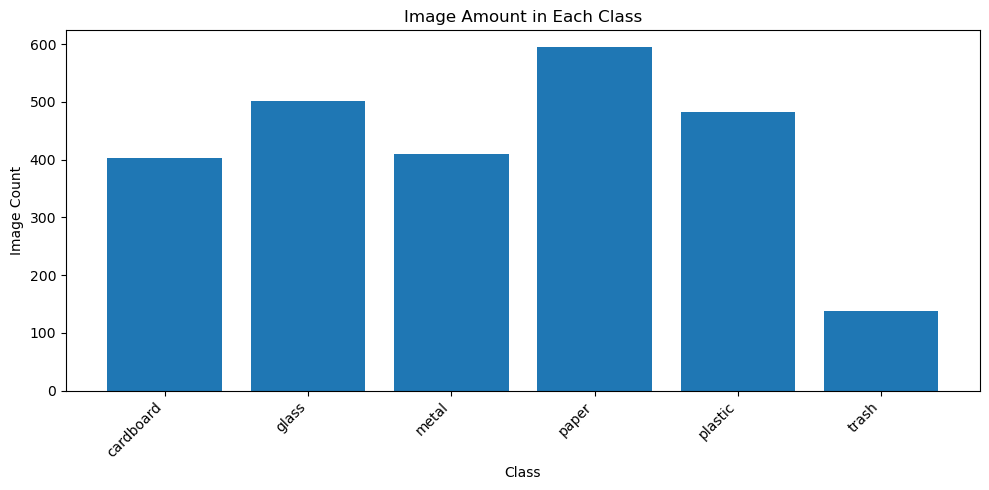

Image total: 2527


In [49]:
DATASET_DIR = "./data"

# Calculate the number of images in each class
class_counts = {}
for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        count = sum(len(files) for _, _, files in os.walk(class_path))
        class_counts[class_name] = count

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.title("Image Amount in Each Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

print(f"Image total: {sum(class_counts.values())}")

## Preprocessing

In [4]:
# Output directory for the split dataset
OUTPUT_DIR = "./data_split"

# Train / Validation / Test split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1


# -------------------------------------------------------------
# 1. Create output folders (train, val, test + class subfolders)
# -------------------------------------------------------------
splits = ["train", "val", "test"]

# Create root directories
for split in splits:
    split_path = os.path.join(OUTPUT_DIR, split)
    os.makedirs(split_path, exist_ok=True)

# List all class folders inside the dataset
classes = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]

# Create class subfolders inside train, val, test
for cls in classes:
    for split in splits:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)


# -------------------------------------------------------------
# 2. Split images for each class
# -------------------------------------------------------------
for cls in classes:

    # Path to the class folder
    class_dir = os.path.join(DATASET_DIR, cls)

    # List all image files
    images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]

    # Shuffle the images
    random.shuffle(images)

    total = len(images)
    n_train = int(total * TRAIN_RATIO)
    n_val = int(total * VAL_RATIO)
    n_test = total - n_train - n_val

    # Process each image
    for i, img in enumerate(images):
        src_path = os.path.join(class_dir, img)

        if i < n_train:
            dst_path = os.path.join(OUTPUT_DIR, "train", cls, img)
        elif i < n_train + n_val:
            dst_path = os.path.join(OUTPUT_DIR, "val", cls, img)
        else:
            dst_path = os.path.join(OUTPUT_DIR, "test", cls, img)

        # Copy the image into the appropriate folder
        shutil.copy(src_path, dst_path)

    print(f"Class '{cls}': {total} images -> {n_train} train, {n_val} val, {n_test} test")

print("\nDataset splitting complete!")
 

Class 'trash': 137 images -> 95 train, 27 val, 15 test
Class 'glass': 501 images -> 350 train, 100 val, 51 test
Class 'plastic': 482 images -> 337 train, 96 val, 49 test
Class 'paper': 594 images -> 415 train, 118 val, 61 test
Class 'metal': 410 images -> 287 train, 82 val, 41 test
Class 'cardboard': 403 images -> 282 train, 80 val, 41 test

Dataset splitting complete!


# Loading dataset into TF

In [4]:
# -------------------------
# Config
# -------------------------
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42 # For reproducibility

# Paths from our earlier processing
TRAIN_DIR = "./data_split/train"
VAL_DIR   = "./data_split/val"
TEST_DIR  = "./data_split/test"

# -------------------------
# Load datasets from directories
# -------------------------
# Note: label_mode="categorical" returns one-hot labels since we have multiple classes.
train_ds = keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Inspect class names and dataset cardinality
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 2290 files belonging to 6 classes.
Found 899 files belonging to 6 classes.
Found 490 files belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train batches: 72
Val batches: 29
Test batches: 16


# Visualizing train/val/test splits

2025-12-08 20:22:51.659223: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-12-08 20:22:51.746321: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


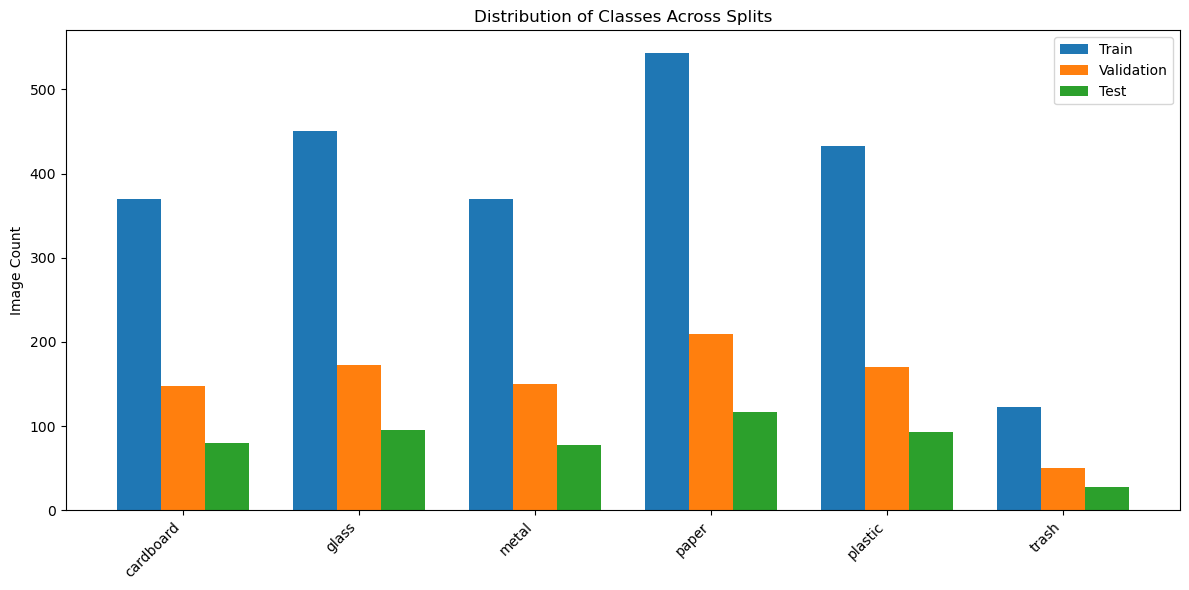

In [5]:
def count_from_dataset(ds):
    labels = []
    for batch in ds:
        y = batch[1].numpy()
        labels.extend(np.argmax(y, axis=1))
    return Counter(labels)

# Calculating number of images in each selection
train_counts = count_from_dataset(train_ds)
val_counts = count_from_dataset(val_ds)
test_counts = count_from_dataset(test_ds)

# Graph
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, [train_counts[i] for i in range(len(class_names))], width, label="Train")
plt.bar(x,         [val_counts[i] for i in range(len(class_names))], width, label="Validation")
plt.bar(x + width, [test_counts[i] for i in range(len(class_names))], width, label="Test")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Image Count")
plt.title("Distribution of Classes Across Splits")
plt.legend()
plt.tight_layout()
plt.show()

# Fetching data optimisations
cache, shuffle, prefetch

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation and Normalization
Flip, rotations, zoom and translation

WARNING: This block is unused because during testing I found out that augmentations tremendously decreased the accuracy of the model. I'll leave it here for future reference.

In [7]:
# Data augmentation block
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
])

# Normalization block
rescale = layers.Rescaling(1./255)

# CNN Creation and Experiments

In [8]:
def build_improved_cnn(num_classes, dropout_rate=0.3):
    model = tf.keras.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model


Running experiment 1: Adam - Baseline (lr=1e-3)
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 364ms/step - accuracy: 0.2707 - loss: 1.7287 - val_accuracy: 0.3982 - val_loss: 1.4798
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 368ms/step - accuracy: 0.4179 - loss: 1.4339 - val_accuracy: 0.4538 - val_loss: 1.3662
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 363ms/step - accuracy: 0.4917 - loss: 1.3020 - val_accuracy: 0.5306 - val_loss: 1.2160
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 368ms/step - accuracy: 0.5485 - loss: 1.1886 - val_accuracy: 0.5373 - val_loss: 1.1450
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 368ms/step - accuracy: 0.5808 - loss: 1.1187 - val_accuracy: 0.6185 - val_loss: 0.9902
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 365ms/step - accuracy: 0.6205 - loss: 1.0305 - val_accuracy: 0.6585 - val_loss: 0.9144
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 376ms/step - accuracy: 0.6550 - loss: 0.9302 - val_accuracy: 0.6897 - val_loss: 0.9049
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 376ms/

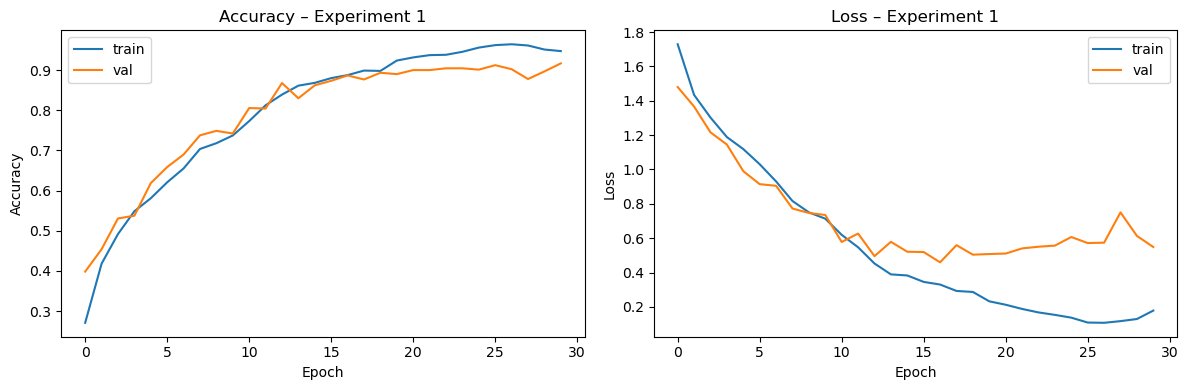


Running experiment 2: Adam - Bigger batch - 64
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 353ms/step - accuracy: 0.3240 - loss: 1.6018 - val_accuracy: 0.4116 - val_loss: 1.4438
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 344ms/step - accuracy: 0.4410 - loss: 1.3665 - val_accuracy: 0.4850 - val_loss: 1.2664
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 344ms/step - accuracy: 0.5358 - loss: 1.2016 - val_accuracy: 0.5651 - val_loss: 1.1492
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 346ms/step - accuracy: 0.5607 - loss: 1.1233 - val_accuracy: 0.5695 - val_loss: 1.1254
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 347ms/step - accuracy: 0.5996 - loss: 1.0628 - val_accuracy: 0.6852 - val_loss: 0.9531
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 348ms/step - accuracy: 0.6555 - loss: 0.9104 - val_accuracy: 0.6719 - val_loss: 0.8724
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 356ms/step - accuracy: 0.6751 - loss: 0.8448 - val_accuracy: 0.6852 - val_loss: 0.8606
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/s

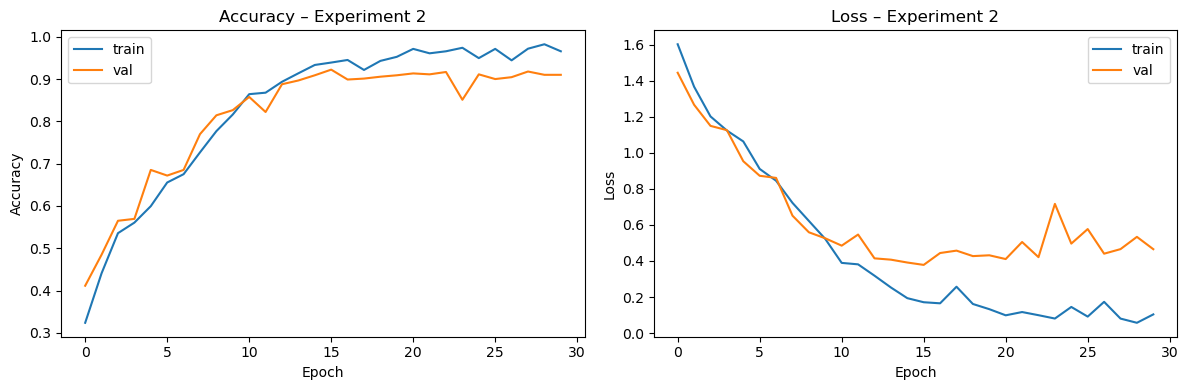


Running experiment 3: Adam - Smaller learning rate - 1e-4
Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.2996 - loss: 1.6308 - val_accuracy: 0.4438 - val_loss: 1.5043
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 355ms/step - accuracy: 0.4428 - loss: 1.4248 - val_accuracy: 0.4794 - val_loss: 1.3328
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 356ms/step - accuracy: 0.4668 - loss: 1.3370 - val_accuracy: 0.4928 - val_loss: 1.3192
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 355ms/step - accuracy: 0.5197 - loss: 1.2599 - val_accuracy: 0.5339 - val_loss: 1.1940
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 356ms/step - accuracy: 0.5489 - loss: 1.1888 - val_accuracy: 0.5640 - val_loss: 1.1829
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.5769 - loss: 1.1143 - val_accuracy: 0.5962 - val_loss: 1.0717
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 353ms/step - accuracy: 0.6052 - loss: 1.0513 - val_accuracy: 0.5873 - val_loss: 1.0465
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 

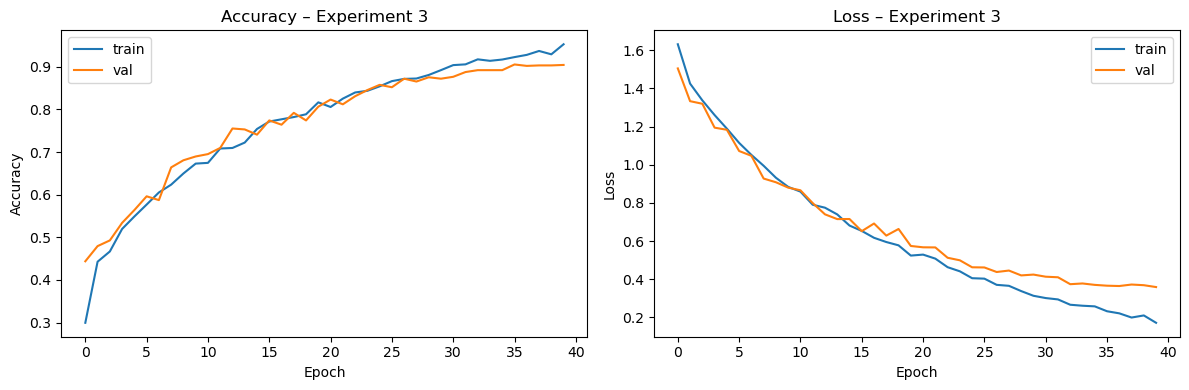


Running experiment 4: RMSprop - Different optimizer
Epoch 1/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 367ms/step - accuracy: 0.2284 - loss: 1.8513 - val_accuracy: 0.3660 - val_loss: 1.5435
Epoch 2/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 351ms/step - accuracy: 0.3524 - loss: 1.5444 - val_accuracy: 0.4527 - val_loss: 1.3382
Epoch 3/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 349ms/step - accuracy: 0.4467 - loss: 1.3790 - val_accuracy: 0.3982 - val_loss: 1.5646
Epoch 4/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 354ms/step - accuracy: 0.5079 - loss: 1.2547 - val_accuracy: 0.5350 - val_loss: 1.1677
Epoch 5/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 355ms/step - accuracy: 0.5616 - loss: 1.1811 - val_accuracy: 0.6329 - val_loss: 1.0244
Epoch 6/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.6092 - loss: 1.0576 - val_accuracy: 0.6452 - val_loss: 1.0100
Epoch 7/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 364ms/step - accuracy: 0.6467 - loss: 0.9565 - val_accuracy: 0.7030 - val_loss: 0.8684
Epoch 8/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 36

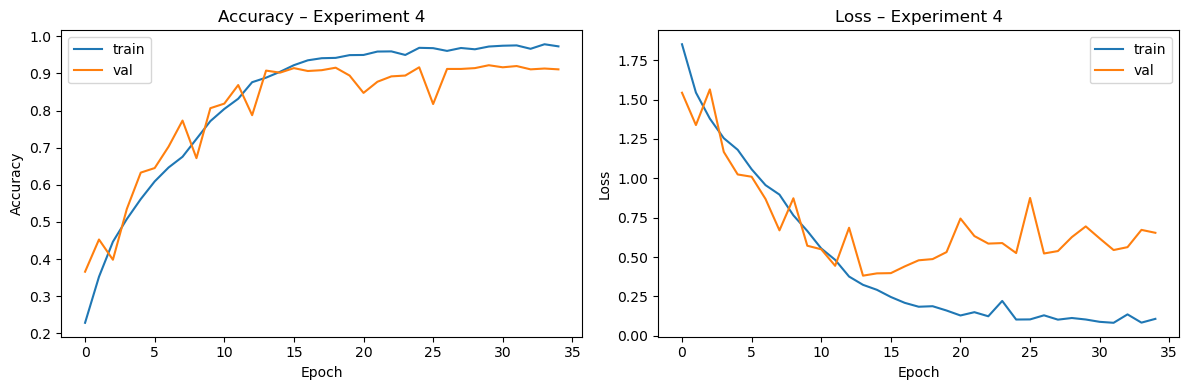


Running experiment 5: Adam - more epochs - 50
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.2681 - loss: 1.6595 - val_accuracy: 0.2992 - val_loss: 1.5346
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 360ms/step - accuracy: 0.4550 - loss: 1.3836 - val_accuracy: 0.5028 - val_loss: 1.2642
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 361ms/step - accuracy: 0.4956 - loss: 1.2685 - val_accuracy: 0.5339 - val_loss: 1.1966
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 370ms/step - accuracy: 0.5638 - loss: 1.1331 - val_accuracy: 0.6040 - val_loss: 1.1193
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 363ms/step - accuracy: 0.6201 - loss: 1.0221 - val_accuracy: 0.6229 - val_loss: 0.9543
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 355ms/step - accuracy: 0.6568 - loss: 0.9272 - val_accuracy: 0.6763 - val_loss: 0.8908
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.6930 - loss: 0.8080 - val_accuracy: 0.7464 - val_loss: 0.7293
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 357ms/st

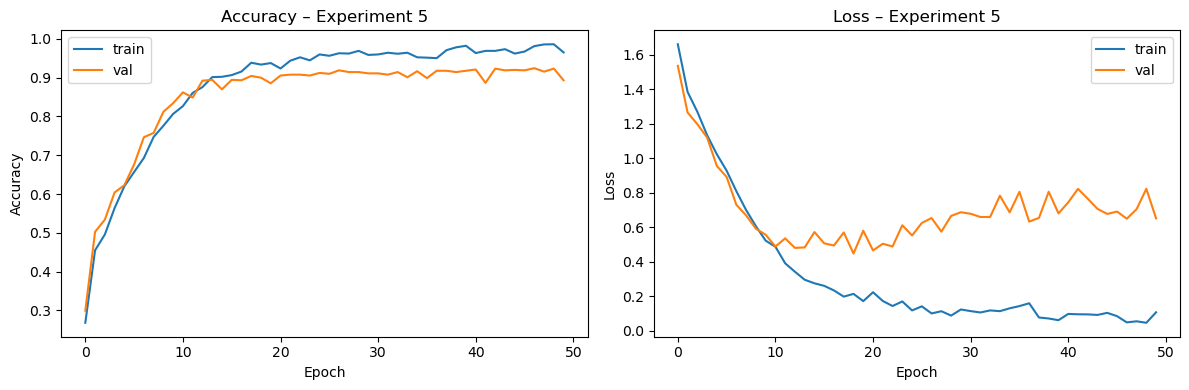

   Experiment                                 Name Optimizer  Batch size  \
0           1            Adam - Baseline (lr=1e-3)      Adam          32   
1           2             Adam - Bigger batch - 64      Adam          64   
2           3  Adam - Smaller learning rate - 1e-4      Adam          32   
3           4        RMSprop - Different optimizer   RMSprop          32   
4           5              Adam - more epochs - 50      Adam          32   

   Epochs  Accuracy (%)  Final loss  
0      30         94.72      0.1787  
1      30         96.55      0.1035  
2      40         95.28      0.1720  
3      35         97.29      0.1073  
4      50         96.51      0.1069  


In [ ]:
experiments = [
    {
        "name": "Adam - Baseline (lr=1e-3)",
        "optimizer": keras.optimizers.Adam(1e-3),
        "batch": 32,
        "epochs": 30
    },
    {
        "name": "Adam - Bigger batch - 64",
        "optimizer": keras.optimizers.Adam(1e-3),
        "batch": 64,
        "epochs": 30
    },
    {
        "name": "Adam - Smaller learning rate - 1e-4",
        "optimizer": keras.optimizers.Adam(1e-4),
        "batch": 32,
        "epochs": 40
    },
    {
        "name": "RMSprop - Different optimizer",
        "optimizer": keras.optimizers.RMSprop(1e-3),
        "batch": 32,
        "epochs": 35
    },
    {
        "name": "Adam - more epochs - 50",
        "optimizer": keras.optimizers.Adam(1e-3),
        "batch": 32,
        "epochs": 50
    }
]

results = []

for i, cfg in enumerate(experiments, start=1):
    print(f"\nRunning experiment {i}: {cfg['name']}")

    model = build_improved_cnn(num_classes)

    model.compile(
        optimizer=cfg["optimizer"],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        verbose=1
    )

    final_acc = history.history["accuracy"][-1]
    final_loss = history.history["loss"][-1]

    results.append({
        "Experiment": i,
        "Name": cfg["name"],
        "Optimizer": cfg["optimizer"].__class__.__name__,
        "Batch size": cfg["batch"],
        "Epochs": cfg["epochs"],
        "Accuracy (%)": round(final_acc * 100, 2),
        "Final loss": round(final_loss, 4)
    })

    # ----- plots -----
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(f"Accuracy – Experiment {i}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["train", "val"])

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(f"Loss – Experiment {i}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["train", "val"])

    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results)

print(df_results)

# Model selection and Recompilation

In [9]:
# Build model with best parameters
final_model = build_improved_cnn(num_classes)

final_model.compile(
    optimizer=keras.optimizers.RMSprop(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback to save best model by validation accuracy
checkpoint = keras.callbacks.ModelCheckpoint(
    "model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train final model
final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.2203 - loss: 2.0335
Epoch 1: val_accuracy improved from None to 0.34594, saving model to model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 356ms/step - accuracy: 0.2467 - loss: 1.8201 - val_accuracy: 0.3459 - val_loss: 1.5977
Epoch 2/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.3626 - loss: 1.5781
Epoch 2: val_accuracy improved from 0.34594 to 0.45050, saving model to model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 356ms/step - accuracy: 0.3886 - loss: 1.5464 - val_accuracy: 0.4505 - val_loss: 1.4103
Epoch 3/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.4622 - loss: 1.3866
Epoch 3: val_accuracy improved from 0.45050 to 0.49055, saving model to model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 374ms/step - accuracy: 0.4489 - loss: 1.3875 - val_accuracy: 0.4905 - val_loss: 1.2706
Epoch 4/35
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5243 - loss: 1.2149
Epoch 4: val_accuracy improved from 0.49055 to 0.6095

# Loading saved model

In [52]:
final_model = keras.models.load_model("model.keras")

# Testing on test set

In [54]:
test_loss, test_acc = final_model.evaluate(test_ds, verbose=1)

print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9163 - loss: 0.7734
Test accuracy: 91.63%
Test loss: 0.7734


# Specific testing for garbage classification

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


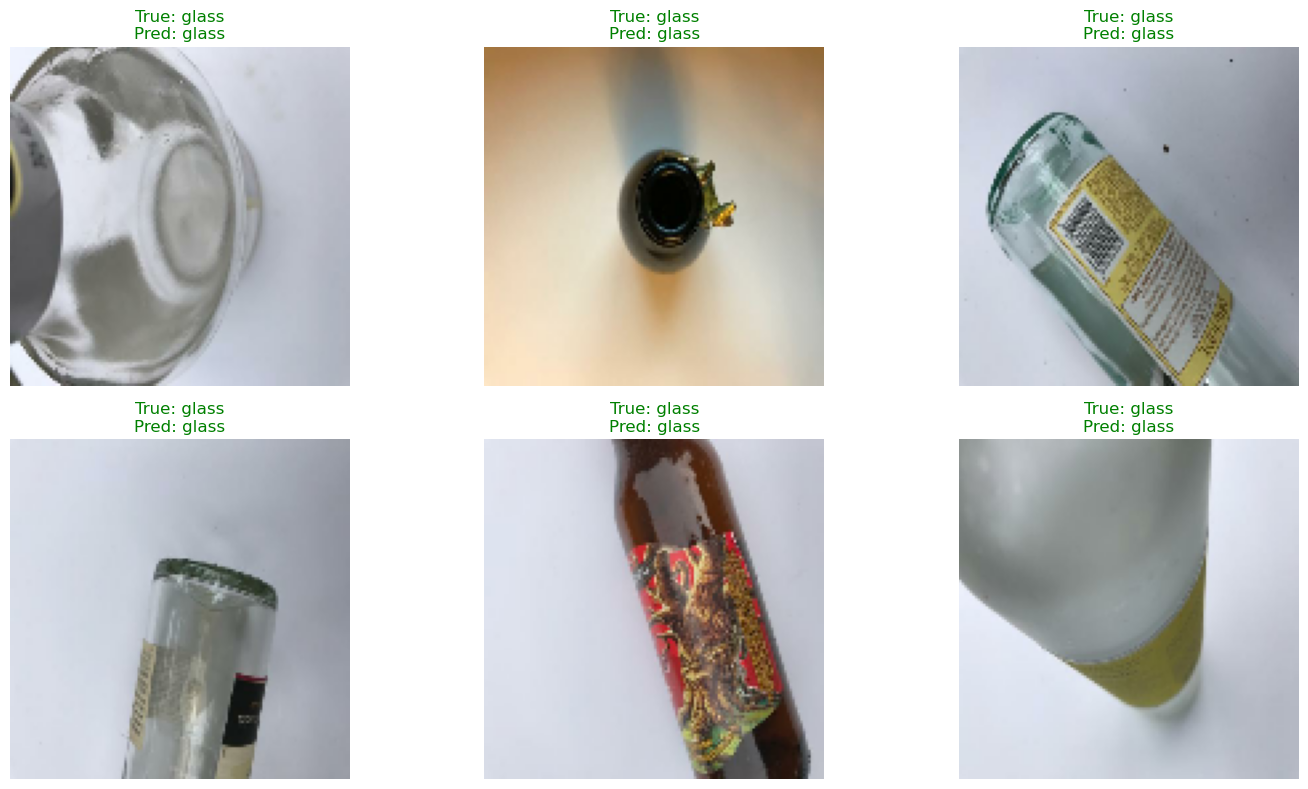

In [63]:
# Create a shuffled test dataset to sample random batches
random_test_ds = test_ds.shuffle(
    buffer_size=1000,
    reshuffle_each_iteration=True
)

# Get one batch from test dataset
images, labels = next(iter(random_test_ds))

# Make predictions
predictions = final_model.predict(images)

# How many images to show
num_images = 6
plt.figure(figsize=(15, 8))

for i in range(num_images):
    true_label = np.argmax(labels[i])
    pred_label = np.argmax(predictions[i])

    true_class = class_names[true_label]
    pred_class = class_names[pred_label]

    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

    title_color = "green" if true_label == pred_label else "red"
    plt.title(
        f"True: {true_class}\nPred: {pred_class}",
        color=title_color
    )

plt.tight_layout()
plt.show()

# Predicting Random Chosen Image

In [25]:
def predict_single_image(image_path, model, class_names):
    # Load image from disk
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE[0], IMG_SIZE[1])
    )

    # Convert PIL image to tensor
    img_array = keras.utils.img_to_array(img)

    # Add batch dimension: (H, W, C) -> (1, H, W, C)
    img_array = tf.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_array)
    pred_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    print(f"Predictions: {predictions}")
    print(f"Class names: {class_names}")

    # Visualization
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_index]}\nConfidence: {confidence:.2f}"
    )
    plt.show()

    return class_names[pred_index], confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predictions: [[1.0000000e+00 6.1735237e-24 1.5528531e-30 2.5749497e-25 3.7396882e-26
  5.4814962e-37]]
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


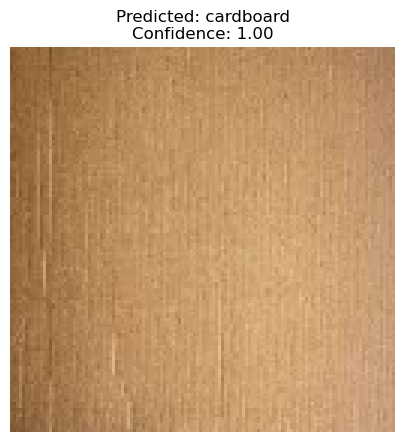

Predicted class: cardboard
Confidence: 1.0


In [51]:
image_path = "./images/cardboard2.png"

predicted_class, confidence = predict_single_image(
    image_path=image_path,
    model=final_model,
    class_names=class_names
)

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

In [27]:
final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,870,798 (26.21 MB)

 Trainable params: 3,435,398 (13.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,435,400 (13.11 MB)

---

# Auxilary: CNN Creation & Experiments
Legacy 7 experiments with batch normalization, data augmentation and EfficientNet

In [13]:
# Make results directory
os.makedirs("results", exist_ok=True)


# -------------------------
# 1. Basic CNN builder
# -------------------------
def build_basic_cnn(num_classes, dropout_rate=0.3, bn=False):
    def conv_block(filters):
        block = []
        block.append(layers.Conv2D(filters, 3, padding="same", activation="relu"))
        if bn:
            block.append(layers.BatchNormalization())
        block.append(layers.MaxPooling2D())
        return block

    layers_list = [
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        *conv_block(64),
        *conv_block(128),
        *conv_block(128),
        layers.Flatten(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ]

    return keras.Sequential(layers_list)



# -------------------------
# 2. Data augmentation layers
# -------------------------
def get_augmenter(mode="light"):
    if mode == "light":
        return keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1)
        ])
    elif mode == "strong":
        return keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.2)
        ])
    return None


# -------------------------
# 3. EfficientNet builder
# -------------------------
def build_efficientnet(num_classes, trainable=False, unfreeze_from=None, dropout_rate=0.3):
    # Load EfficientNetB0 backbone
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Set trainability
    base.trainable = trainable

    # Partial unfreezing
    if unfreeze_from is not None:
        for layer in base.layers[:-unfreeze_from]:
            layer.trainable = False
        for layer in base.layers[-unfreeze_from:]:
            layer.trainable = True

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = inputs

    x = base(x, training=trainable)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model


# -------------------------
# 4. Training function
# -------------------------
def train_experiment(cfg, exp_id):

    print(f"\n=== Running experiment {exp_id}: {cfg['name']} ===")

    # Select model based on type
    if cfg["model"] == "cnn":
        model = build_basic_cnn(
            num_classes=num_classes,
            dropout_rate=cfg.get("dropout", 0.3),
            bn=cfg.get("bn", False)
        )
    elif cfg["model"] == "efficientnet":
        model = build_efficientnet(
            num_classes=num_classes,
            trainable=cfg.get("trainable", False),
            unfreeze_from=cfg.get("unfreeze", None),
            dropout_rate=cfg.get("dropout", 0.3)
        )

    # Add augmentation if needed
    if cfg["aug"] is not None:
        aug = get_augmenter(cfg["aug"])
        train_data = train_ds.map(lambda x, y: (aug(x), y))
    else:
        train_data = train_ds

    # Compile
    model.compile(
        optimizer=cfg["optimizer"],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = []
    if cfg.get("lr_schedule"):
        callbacks.append(
            keras.callbacks.ReduceLROnPlateau(factor=0.4, patience=3)
        )
    if cfg.get("early_stop"):
        callbacks.append(
            keras.callbacks.EarlyStopping(patience=cfg.get("early_stop_patience", 6), restore_best_weights=True)
        )

    # Train
    history = model.fit(
        train_data,
        validation_data=val_ds,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        class_weight=cfg.get("class_weights"),
        callbacks=callbacks,
        verbose=1
    )

    # Final accuracy
    final_acc = history.history["accuracy"][-1] * 100
    final_loss = history.history["loss"][-1]

    # Save plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    ax[0].plot(history.history["accuracy"])
    ax[0].plot(history.history["val_accuracy"])
    ax[0].set_title("Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend(["train", "val"])

    # Loss plot
    ax[1].plot(history.history["loss"])
    ax[1].plot(history.history["val_loss"])
    ax[1].set_title("Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend(["train", "val"])

    plt.savefig(f"results/experiment_{exp_id}_plots.png")
    plt.close()

    return {
        "Experiment": exp_id,
        "Name": cfg["name"],
        "Optimizer": cfg["optimizer"].__class__.__name__,
        "Augmentation": cfg["aug"],
        "Model": cfg["model"],
        "Batch": cfg["batch"],
        "Epochs": cfg["epochs"],
        "Other": cfg.get("desc", "-"),
        "Accuracy (%)": round(final_acc, 2),
        "Final loss": round(final_loss, 4)
    }


# -------------------------
# 5. Experiment configs
# -------------------------
experiments = [

    {
        "name": "Improved CNN baseline",
        "model": "cnn",
        "optimizer": keras.optimizers.Adam(1e-3),
        "epochs": 30,
        "batch": 32,
        "aug": None,
        "desc": "baseline improved CNN"
    },

    {
        "name": "CNN + light augmentation",
        "model": "cnn",
        "optimizer": keras.optimizers.Adam(1e-3),
        "epochs": 35,
        "batch": 32,
        "aug": "light",
    },

    {
        "name": "CNN + LR schedule",
        "model": "cnn",
        "optimizer": keras.optimizers.Adam(1e-3),
        "epochs": 40,
        "batch": 32,
        "aug": "light",
        "lr_schedule": True,
        "early_stop": True,
    },

    {
        "name": "CNN + BatchNorm",
        "model": "cnn",
        "optimizer": keras.optimizers.Adam(1e-3),
        "epochs": 40,
        "batch": 32,
        "aug": "light",
        "bn": True,
        "desc": "CNN with BatchNorm layers",
    },


    {
        "name": "EfficientNetB0 frozen",
        "model": "efficientnet",
        "trainable": False,
        "optimizer": keras.optimizers.Adam(1e-3),
        "epochs": 20,
        "batch": 32,
        "aug": "light",
    },

    {
        "name": "EfficientNetB0 partial unfreeze",
        "model": "efficientnet",
        "trainable": True,
        "unfreeze": 60,  # number of layers to unfreeze
        "optimizer": keras.optimizers.Adam(1e-4),
        "epochs": 25,
        "batch": 32,
        "aug": "light",
        "lr_schedule": True,
        "early_stop": True,
    },

    {
        "name": "EfficientNetB0 full fine-tune",
        "model": "efficientnet",
        "trainable": True,
        "optimizer": keras.optimizers.Adam(5e-5),
        "epochs": 40,
        "batch": 32,
        "aug": "strong",
        "lr_schedule": True,
        "early_stop": True,
        "desc": "full fine-tune + strong augmentation"
    }
]

# -------------------------
# 6. Run all experiments
# -------------------------
results = []
for i, cfg in enumerate(experiments, start=1):
    out = train_experiment(cfg, i)
    results.append(out)

df = pd.DataFrame(results)
# df.to_csv("results/summary.csv", index=False)

print(df)


=== Running experiment 1: Improved CNN baseline ===
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.2908 - loss: 16.1543 - val_accuracy: 0.3582 - val_loss: 1.5490
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 442ms/step - accuracy: 0.3782 - loss: 1.5346 - val_accuracy: 0.4461 - val_loss: 1.3700
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 436ms/step - accuracy: 0.4441 - loss: 1.3948 - val_accuracy: 0.4683 - val_loss: 1.3440
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 435ms/step - accuracy: 0.4747 - loss: 1.3090 - val_accuracy: 0.5239 - val_loss: 1.2284
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 437ms/step - accuracy: 0.5284 - loss: 1.1663 - val_accuracy: 0.5840 - val_loss: 1.1921
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 438ms/step - accuracy: 0.6144 - loss: 1.0236 - val_accuracy: 0.6185 - val_loss: 1.0102
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 438ms/step - accuracy: 0.6493 - loss: 0.9117 - val_accuracy: 0.7019 - val_loss: 0.9235
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 4